# <h1 style="text-align: center;">Optimal Control of TCLab using a Gaussian process regression embedded in Pyomo</h1>

<h2 style="text-align: center;">Notebook v7</h2>

<p style="text-align: center;">Alex Dowling<sup>a</sup>, Jacob P. Krell<sup>b</sup>, David S. Mebane<sup>b</sup>

<p style="text-align: center;"><sup>a</sup>Department of Chemical and Biomolecular Engineering, University of Notre Dame, Notre Dame, IN 46556, USA <br>
<sup>b</sup>Department of Mechanical and Aerospace Engineering, West Virginia University, Morgantown, WV, 26506-6106, USA</p>

## Change Log

- adapted from *pyomo_tclab_v6_optimize1_with_v5c2.ipynb*
- previously internal ```fokl_to_pyomo``` function accessed through updated FoKL module

## Script

In [1]:
# =====================================================================
# =====================================================================
# MODULES:

from FoKL import FoKLRoutines
import os
dir = os.path.abspath('')  # directory of notebook
# -----------------------------------------------------------------------
# UNCOMMENT IF USING LOCAL FOKL PACKAGE:
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
# =====================================================================
# =====================================================================
# LOAD AND PARSE SINE TEST DATA:

data = pd.read_csv(os.path.join(dir, "data", "tclab_sine_test.csv"))

tvec = data["Time"].values
Q1 = data["Q1"].values
TS1 = data["T1"].values

Q1f = interp1d(tvec, Q1, kind='previous')  # piecewise Q1
dQ1f_analytic = lambda t: 1500 * np.cos(30 * np.pi * t / tvec[-1]) * np.pi / tvec[-1]  # derivative of analytic Q1
dQ1f = interp1d(tvec, dQ1f_analytic(tvec), kind='previous')  # piecewise derivative of analytic Q1

In [3]:
# =====================================================================
# =====================================================================
# SMOOTHING OF SINE TEST:

window = 9  # odd number, mean at center +/- floor(window/2))

def smooth(TS1, window):
    """Apply centered average of size window."""
    TS1_smooth = np.zeros_like(TS1)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        TS1_smooth[i] = np.mean(TS1[:(i + w2p1)])

    # center:
    for i in range(w2, TS1_smooth.size - w2):
        TS1_smooth[i] = np.mean(TS1[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        TS1_smooth[i] = np.mean(TS1[(i - w2)::])

    return TS1_smooth

TS1_smooth = smooth(TS1, window)

In [4]:
# =====================================================================
# =====================================================================
# DERIVATIVE OF SMOOTHED SINE TEST:

def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

dTS1 = gradient_h4(TS1_smooth, tvec[1] - tvec[0])
dTS1f = interp1d(tvec, dTS1, kind='previous')  # piecewise, grab previous value

/home/jacobpatrick/ESMS/dev/tclab/examples/pyomo_tclab/../../src/FoKL/FoKLRoutines.py:290: UserWarning: 'inputs' was transposed. Ignore if more datapoints than input variables, else set 'AutoTranspose=False' to disable.
  warnings.warn("'inputs' was transposed. Ignore if more datapoints than input variables, else set "


[1, -3486.355364597256]
[2, -3485.1148892427345]
[2, -3484.309184417928]
[3, -3482.8900616975807]


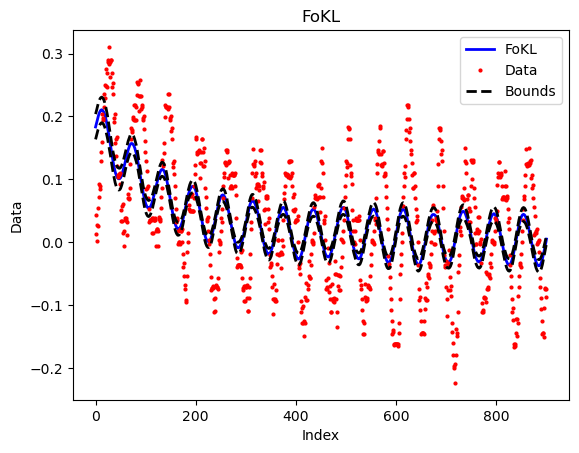

In [12]:
# =====================================================================
# =====================================================================
# GP MODEL OF DIFFERENTIATED SINE TEST:

Q1_cos = np.max(np.abs(Q1 - 50)) * np.cos(30 * np.pi * tvec / tvec[-1]) + 50  # train on lagged signal, i.e., derivative of periodic signal in terms of phase but retain amplitude
Q1_cos[Q1_cos < 0] = 0
Q1_cos[Q1_cos > 100] = 100

GP_dT = FoKLRoutines.FoKL(kernel=1, aic=True)
GP_dT.fit([TS1_smooth, Q1_cos], dTS1, clean=True, minmax=[[20, 70], [0, 100]])

_ = GP_dT.coverage3(plot=True)

In [6]:
# =====================================================================
# =====================================================================
# CONTROLLER REFERENCE TRAJECTORY:

# time grid
t0 = 0
tf = 999
dt = 1
n = round(tf / dt)
t_grid = np.linspace(t0, tf, n + 1)

# ambient temperature
Tamb = 21.0

# time points of setpoint/reference values
tr = [t0, 50, 150, 450, 550, tf]

# setpoint/reference
def r(t):
    return np.interp(t, tr, [Tamb, Tamb, 60, 60, 35, 35])

# derivative of setpoint/reference
dr = interp1d(tr, [0, (60 - Tamb) / 100, 0, (35 - 60) / 100, 0, 0], kind='previous')

In [7]:
# =====================================================================
# =====================================================================
# ODE USING BENCHMARK RESULTS, TO CONFRIM GP PERFORMANCE:

# Fix u1 to benchmark solution, forcing 0 DoF for sake of debugging:

u1_benchmark = np.loadtxt(os.path.join(dir, 'data', 'u1_benchmark_solution.csv'), delimiter=',')
u1_benchmark = np.concatenate([np.array([t0, 0])[np.newaxis, :],
                               u1_benchmark[1:107, :],
                               u1_benchmark[130:218, :],
                               u1_benchmark[243:354, :],
                               u1_benchmark[370:-1, :]], axis=0)  # remove oscillations/outliers

def u1_ref(t):
    """u1 values from benchmark solution."""
    u1 = np.interp(t, u1_benchmark[:, 0], u1_benchmark[:, 1])
    
    if isinstance(u1, float):
        u1 = np.array([u1])
    
    for i in range(len(u1)):
        if u1[i] < 0:
            u1[i] = 0
        elif u1[i] > 100:
            u1[i] = 100
    
    if len(u1) == 1:
        return u1[0]  # float
    else:
        return u1  # ndarray

du1_benchmark = np.array([u1_benchmark[:, 0], np.gradient(u1_benchmark[:, 1], u1_benchmark[:, 0])]).T
du1_benchmark = np.concatenate([du1_benchmark[:10, :], du1_benchmark[13::, :]], axis=0)  # remove oscillations/outliers

def du1_ref(t):
    """du1 values via u1 from benchmark solution."""
    return np.interp(t, du1_benchmark[:, 0], du1_benchmark[:, 1])

In [8]:
# Evaluate ODE:

def dy(t, y):
    """ODE"""
    Ts1_i = y[0]
    dTs1_i = GP_dT.evaluate([Ts1_i, u1_ref(t)], clean=True, SingleInstance=True)[0]
    # dTs1_i = dr(t)  # USED TO DEBUG SOLVE_IVP PARAMETERS, SINCE NOT IMMEDIATELY MATCHING R(T) IN PLOT
    return [dTs1_i]

# soln = solve_ivp(dy, [t0, tf], [Tamb], t_eval=t_grid, method="RK45", first_step=1, min_step=1, max_step=1)  # WORKS FOR DR(T), NOT FOR GP (~9 MINS SOLVE TIME)
soln = solve_ivp(dy, [t0, tf], [Tamb], t_eval=t_grid, method="LSODA", first_step=1, min_step=1, max_step=1)  # FAILED ALSO, BUT ~3 MINS

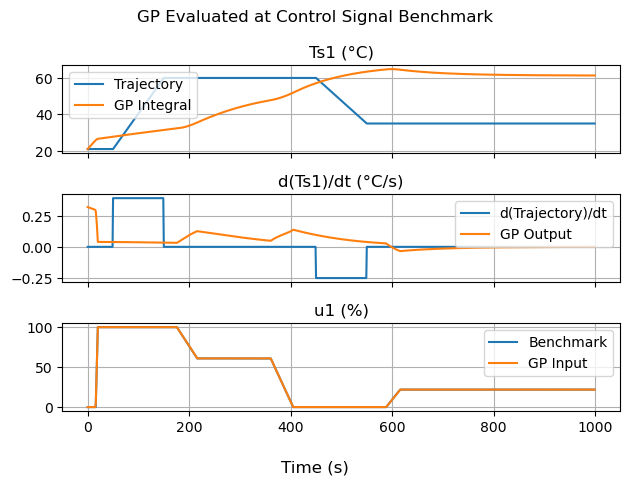

In [10]:
# Plot:

fig, axs = plt.subplots(3, sharex=True)
fig.suptitle("GP Evaluated at Control Signal Benchmark")
fig.supxlabel("Time (s)")

axs[0].set_title("Ts1 (°C)")
axs[0].plot(tr, r(tr), label="Trajectory")
axs[0].plot(t_grid, soln.y[0], label="GP Integral")

axs[1].set_title("d(Ts1)/dt (°C/s)")
axs[1].plot(t_grid, dr(t_grid), label="d(Trajectory)/dt")
axs[1].plot(t_grid, GP_dT.evaluate([soln.y[0], u1_ref(t_grid)], clean=True), label="GP Output")

axs[2].set_title("u1 (%)")
axs[2].plot(u1_benchmark[:, 0], u1_benchmark[:, 1], label="Benchmark")
axs[2].plot(soln.t, u1_ref(soln.t), label="GP Input")

for i in range(3):
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()

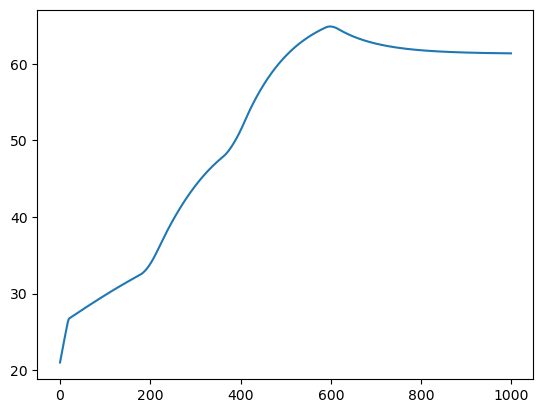

In [11]:
# =====================================================================
# =====================================================================
# MANUAL INTEGRATION TO CONFIRM GP IS OK, BUT THAT ODE IS NOT:

Ts1_int = np.zeros_like(t_grid)
Ts1_int[0] = Tamb  # IC

for i in range(1, len(t_grid)):
    Ts1_int[i] = Ts1_int[i - 1] + (t_grid[i] - t_grid[i - 1]) * GP_dT.evaluate([Ts1_int[i - 1], u1_ref(t_grid[i - 1])], clean=True, SingleInstance=True)[0]

plt.plot(t_grid, Ts1_int)